In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/upi_transactions_2024.csv")

df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [8]:
df.shape
df.columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [9]:
df['transaction_status'].unique()

array(['SUCCESS', 'FAILED'], dtype=object)

In [10]:

df['sender_state'].unique()


array(['Delhi', 'Uttar Pradesh', 'Karnataka', 'Telangana', 'Maharashtra',
       'Gujarat', 'Rajasthan', 'Tamil Nadu', 'West Bengal',
       'Andhra Pradesh'], dtype=object)

In [11]:

df['device_type'].unique()

array(['Android', 'iOS', 'Web'], dtype=object)

In [12]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)


In [13]:
df.columns

Index(['transaction_id', 'timestamp', 'transaction_type', 'merchant_category',
       'amount_inr', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [14]:
df.isnull().sum()


,0
transaction_id,0
timestamp,0
transaction_type,0
merchant_category,0
amount_inr,0
transaction_status,0
sender_age_group,0
receiver_age_group,0
sender_state,0
sender_bank,0


In [15]:
df['timestamp'] = pd.to_datetime(df['timestamp'])


In [16]:
df['amount_inr'] = pd.to_numeric(df['amount_inr'], errors='coerce')


In [17]:
df['transaction_status'] = df['transaction_status'].str.upper().str.strip()
df['device_type'] = df['device_type'].str.upper().str.strip()
df['sender_state'] = df['sender_state'].str.title().str.strip()


In [18]:
df['device_type'].unique()


array(['ANDROID', 'IOS', 'WEB'], dtype=object)

In [19]:
df.duplicated().sum()


np.int64(0)

In [20]:
df['txn_hour'] = df['timestamp'].dt.hour
df['txn_date'] = df['timestamp'].dt.date
df['day_of_week'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.month
df['is_weekend'] = df['day_of_week'].isin(['Saturday','Sunday']).astype(int)


In [21]:
df['amount_inr'].describe()


,amount_inr
count,250000.000000
mean,1311.756036
std,1848.059224
min,10.000000
25%,288.000000
50%,629.000000
75%,1596.000000
max,42099.000000


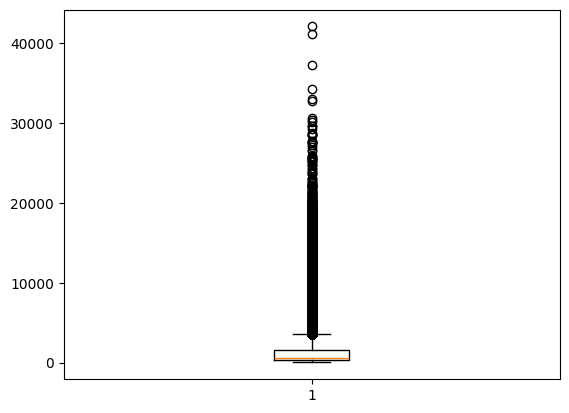

In [22]:
import matplotlib.pyplot as plt

plt.boxplot(df['amount_inr'])
plt.show()


In [23]:
df = df[df['amount_inr'] < 200000]


In [24]:
df.to_csv("upi_cleaned.csv", index=False)


In [77]:
from google.colab import files
files.download("upi_cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**feature Engineering**

In [26]:
import pandas as pd

df = pd.read_csv("upi_cleaned.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])

df.head()


,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,txn_hour,txn_date,month
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,ANDROID,4G,0,15,Tuesday,0,15,2024-10-08,10
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,IOS,4G,0,6,Thursday,0,6,2024-04-11,4
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,ANDROID,4G,0,13,Tuesday,0,13,2024-04-02,4
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,ANDROID,5G,0,10,Sunday,1,10,2024-01-07,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,IOS,WiFi,0,19,Tuesday,0,19,2024-01-23,1


In [27]:
df['txn_hour'] = df['timestamp'].dt.hour


In [28]:
df['txn_date'] = df['timestamp'].dt.date


In [29]:
df['day_name'] = df['timestamp'].dt.day_name()


In [30]:
df['month'] = df['timestamp'].dt.month


In [31]:
df['is_weekend'] = df['day_name'].isin(['Saturday', 'Sunday']).astype(int)


**Peak Time Classification**

In [32]:
def classify_peak(hour):
    if 7 <= hour <= 10:
        return "Morning Peak"
    elif 18 <= hour <= 22:
        return "Evening Peak"
    elif 11 <= hour <= 17:
        return "Mid Day"
    else:
        return "Late Night"

df['peak_category'] = df['txn_hour'].apply(classify_peak)


**Failure Flag**

In [33]:
df['failure_flag'] = (df['transaction_status'] == 'FAILED').astype(int)


**Transaction Amount Segmentation (Better Than Removing Outliers)**

In [34]:
df['amount_category'] = pd.cut(
    df['amount_inr'],
    bins=[0, 500, 2000, 10000, 50000],
    labels=['Low', 'Medium', 'High', 'Very High']
)


Daily Transaction Count (Trend Feature)

In [35]:
daily_counts = df.groupby('txn_date').size().reset_index(name='daily_txns')

df = df.merge(daily_counts, on='txn_date', how='left')


Rolling 7-Day Transaction Volume (Advanced Feature)

In [36]:
daily_counts['rolling_7_day'] = daily_counts['daily_txns'].rolling(7).sum()

df = df.merge(
    daily_counts[['txn_date', 'rolling_7_day']],
    on='txn_date',
    how='left'
)


Hourly Load Category (Operational Insight)

In [37]:
hourly_counts = df.groupby('txn_hour').size().reset_index(name='hourly_txns')

avg_hourly = hourly_counts['hourly_txns'].mean()

df = df.merge(hourly_counts, on='txn_hour', how='left')

df['load_category'] = df['hourly_txns'].apply(
    lambda x: 'High Load' if x > avg_hourly else 'Normal Load'
)


State-Level Failure Rate (Risk Feature)

In [38]:
state_stats = df.groupby('sender_state').agg(
    total_txns=('transaction_id', 'count'),
    failures=('failure_flag', 'sum')
).reset_index()

state_stats['state_failure_rate'] = (
    state_stats['failures'] / state_stats['total_txns']
) * 100

df = df.merge(
    state_stats[['sender_state', 'state_failure_rate']],
    on='sender_state',
    how='left'
)


Device Reliability Feature

In [39]:
device_stats = df.groupby('device_type').agg(
    total_txns=('transaction_id', 'count'),
    failures=('failure_flag', 'sum')
).reset_index()

device_stats['device_failure_rate'] = (
    device_stats['failures'] / device_stats['total_txns']
) * 100

df = df.merge(
    device_stats[['device_type', 'device_failure_rate']],
    on='device_type',
    how='left'
)


Save Engineered Dataset

In [40]:
df.to_csv("upi_feature_engineered.csv", index=False)


In [41]:
from google.colab import files
files.download("upi_feature_engineered.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**EDA**

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("upi_feature_engineered.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

df.head()


,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,day_name,peak_category,failure_flag,amount_category,daily_txns,rolling_7_day,hourly_txns,load_category,state_failure_rate,device_failure_rate
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,...,Tuesday,Mid Day,0,Medium,723,4682.0,12624,High Load,4.973864,4.940967
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,...,Thursday,Late Night,0,Medium,711,4948.0,3501,Normal Load,5.218257,4.934191
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,...,Tuesday,Mid Day,0,Low,653,4707.0,15038,High Load,4.862885,4.940967
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,...,Sunday,Morning Peak,0,High,694,4737.0,13904,High Load,4.973864,4.940967
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,...,Tuesday,Evening Peak,0,Medium,676,4808.0,21232,High Load,4.973864,4.934191


In [43]:
df.shape


(250000, 30)

In [44]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   transaction_id       250000 non-null  object        
 1   timestamp            250000 non-null  datetime64[ns]
 2   transaction_type     250000 non-null  object        
 3   merchant_category    250000 non-null  object        
 4   amount_inr           250000 non-null  int64         
 5   transaction_status   250000 non-null  object        
 6   sender_age_group     250000 non-null  object        
 7   receiver_age_group   250000 non-null  object        
 8   sender_state         250000 non-null  object        
 9   sender_bank          250000 non-null  object        
 10  receiver_bank        250000 non-null  object        
 11  device_type          250000 non-null  object        
 12  network_type         250000 non-null  object        
 13  fraud_flag    

In [45]:
df.isnull().sum()


,0
transaction_id,0
timestamp,0
transaction_type,0
merchant_category,0
amount_inr,0
transaction_status,0
sender_age_group,0
receiver_age_group,0
sender_state,0
sender_bank,0


Transaction Amount Analysis

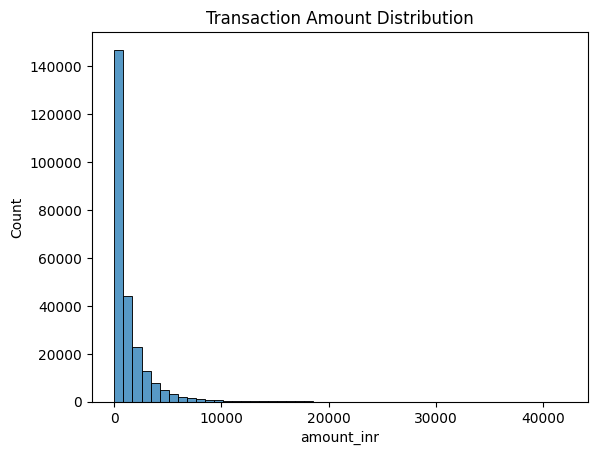

In [46]:
sns.histplot(df['amount_inr'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()


Median Vs Mean

In [47]:
df['amount_inr'].mean()



np.float64(1311.756036)

In [48]:
df['amount_inr'].median()

629.0

Amount Category Breakdown

In [49]:
df['amount_category'].value_counts()


,count
amount_category,
Low,106624
Medium,94221
High,47350
Very High,1805


Peak Hour Analysis

Hourly Transaction Volume

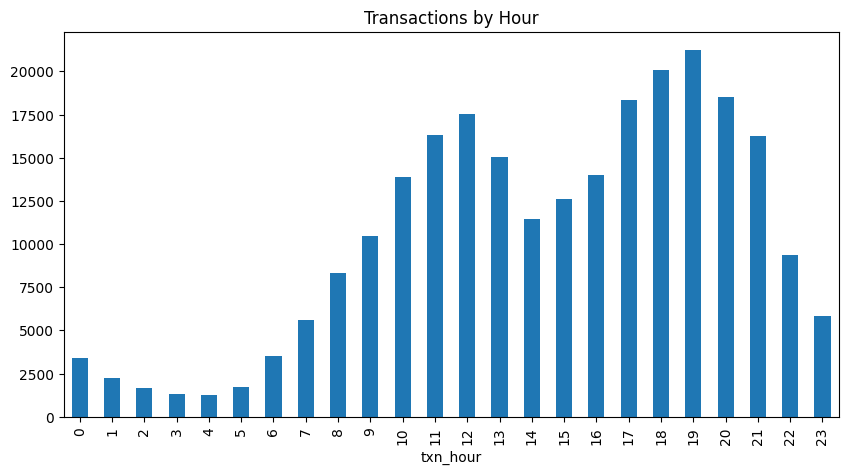

In [50]:
hourly = df.groupby('txn_hour').size()

plt.figure(figsize=(10,5))
hourly.plot(kind='bar')
plt.title("Transactions by Hour")
plt.show()


In [51]:
df['peak_category'].value_counts()


,count
peak_category,
Mid Day,105310
Evening Peak,85419
Morning Peak,38333
Late Night,20938


Failure Pattern Analysis

Overall Failure Rate

In [52]:
failure_rate = df['failure_flag'].mean() * 100
failure_rate


np.float64(4.9504)

Failure by Hour

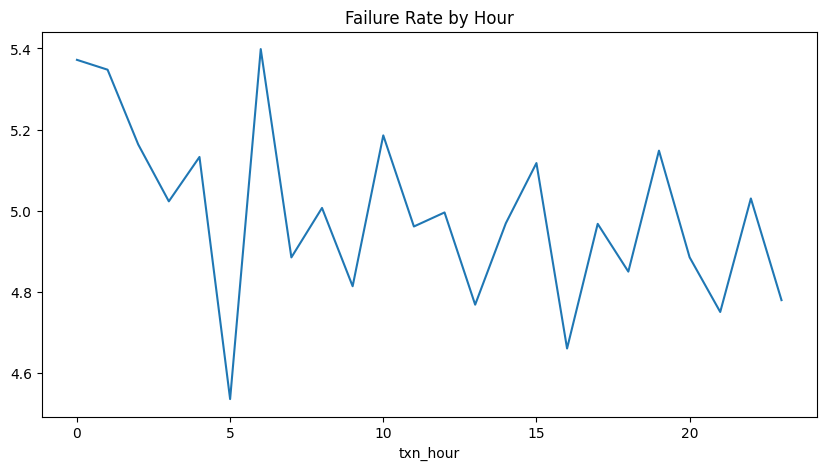

In [53]:
hourly_failure = df.groupby('txn_hour')['failure_flag'].mean() * 100

plt.figure(figsize=(10,5))
hourly_failure.plot(kind='line')
plt.title("Failure Rate by Hour")
plt.show()


Failure by Peak Category

In [54]:
df.groupby('peak_category')['failure_flag'].mean() * 100


,failure_flag
peak_category,
Evening Peak,4.932158
Late Night,5.086446
Mid Day,4.919761
Morning Peak,5.000913


City / State Analysis

Transactions by State

In [55]:
df['sender_state'].value_counts().head(10)


,count
sender_state,
Maharashtra,37427
Uttar Pradesh,30125
Karnataka,29756
Tamil Nadu,25367
Delhi,24870
Telangana,22435
Gujarat,20061
Andhra Pradesh,20006
Rajasthan,19981


Failure Rate by State

In [56]:
state_failure = df.groupby('sender_state')['failure_flag'].mean() * 100
state_failure.sort_values(ascending=False).head(10)


,failure_flag
sender_state,
Uttar Pradesh,5.218257
Tamil Nadu,5.116884
West Bengal,5.042059
Andhra Pradesh,4.998500
Delhi,4.973864
Maharashtra,4.921581
Karnataka,4.862885
Rajasthan,4.794555
Gujarat,4.780420


Device & Network Analysis

Device Distribution

In [57]:
df['device_type'].value_counts()


,count
device_type,
ANDROID,187777
IOS,49613
WEB,12610


Failure by Device

In [58]:
df.groupby('device_type')['failure_flag'].mean() * 100


,failure_flag
device_type,
ANDROID,4.940967
IOS,4.934191
WEB,5.154639


Trend Analysis

Daily Transactions

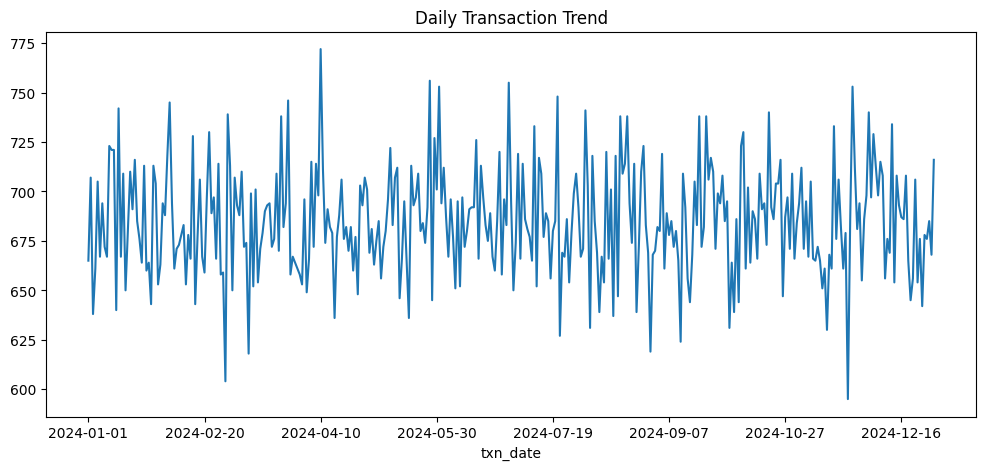

In [59]:
daily = df.groupby('txn_date').size()

plt.figure(figsize=(12,5))
daily.plot()
plt.title("Daily Transaction Trend")
plt.show()


Rolling 7-Day Trend

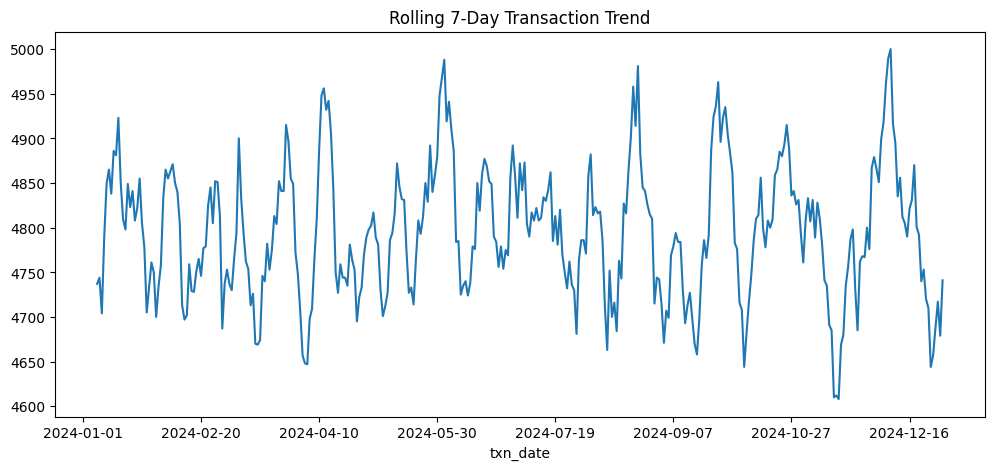

In [60]:
daily_rolling = daily.rolling(7).sum()

plt.figure(figsize=(12,5))
daily_rolling.plot()
plt.title("Rolling 7-Day Transaction Trend")
plt.show()


Load vs Failure Relationship

High Load vs Failure Rate

In [61]:
df.groupby('load_category')['failure_flag'].mean() * 100


,failure_flag
load_category,
High Load,4.932456
Normal Load,5.033762


Amount vs Failure

In [62]:
df.groupby('amount_category')['failure_flag'].mean() * 100


,failure_flag
amount_category,
High,5.068638
Low,4.866634
Medium,4.970230
Very High,5.761773


Key Insights You Should Extract

**Total Transactions**

In [63]:
total_txns = len(df)


**Total Transaction Volume (₹)**

In [64]:
total_volume = df['amount_inr'].sum()


**Success Rate %**

In [65]:
success_rate = (1 - df['failure_flag'].mean()) * 100


**Failure Rate %**

In [66]:
failure_rate = df['failure_flag'].mean() * 100


**Average Transaction Amount (Use Median)**

In [67]:
median_amount = df['amount_inr'].median()


**SECTION 2: Peak & Load KPIs**

In [68]:
peak_hour = df['txn_hour'].value_counts().idxmax()


**Highest Failure Hour**

In [69]:
failure_by_hour = df.groupby('txn_hour')['failure_flag'].mean()
worst_hour = failure_by_hour.idxmax()


**High Load Failure Rate**

In [70]:
df.groupby('load_category')['failure_flag'].mean() * 100


,failure_flag
load_category,
High Load,4.932456
Normal Load,5.033762


**SECTION 3: Risk KPIs**

Top Risk State

In [71]:
state_failure = df.groupby('sender_state')['failure_flag'].mean()
top_risk_state = state_failure.idxmax()


Device Reliability Score

In [72]:
device_failure = df.groupby('device_type')['failure_flag'].mean() * 100


**SECTION 4: Trend KPIs**

Daily Average Transactions

In [73]:
daily_avg = df.groupby('txn_date').size().mean()


7-Day Rolling Growth %

In [74]:
daily = df.groupby('txn_date').size()
rolling = daily.rolling(7).mean()

growth_rate = ((rolling.iloc[-1] - rolling.iloc[-8]) / rolling.iloc[-8]) * 100


**SECTION 5: Behavioral KPIs**

Weekend Failure Rate

In [75]:
df.groupby('is_weekend')['failure_flag'].mean() * 100


,failure_flag
is_weekend,
0,4.894130
1,5.091327


Failure by Amount Category

In [76]:
df.groupby('amount_category')['failure_flag'].mean() * 100


,failure_flag
amount_category,
High,5.068638
Low,4.866634
Medium,4.970230
Very High,5.761773
